<a href="https://colab.research.google.com/github/Elewia/occupancy-aiot-project/blob/main/Project_Person_Count_AIoT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install pymongo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 17.3 MB/s eta 0:00:00


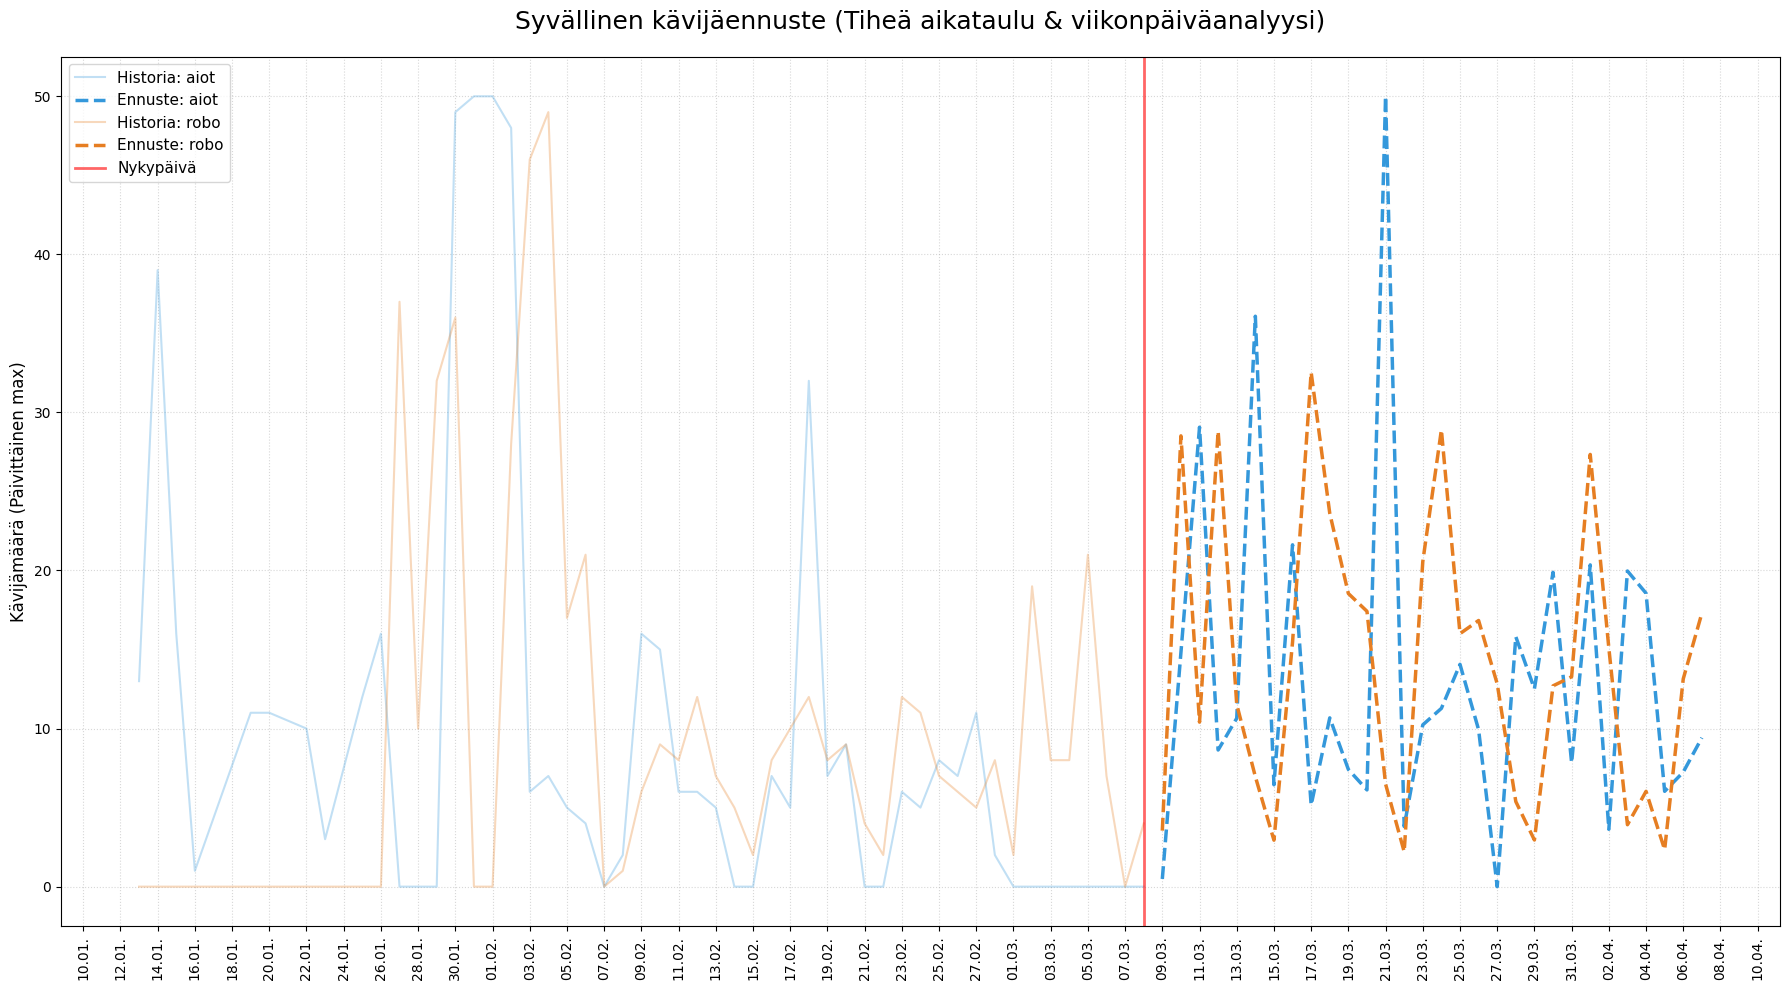

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

# 1. Valmistellaan viikonpäiväanalyysi (varmistetaan muuttujien olemassaolo)
daily_max['weekday'] = pd.to_datetime(daily_max.index).weekday
future_days = 30
last_date = pd.to_datetime(daily_max.index[-1])
future_dates = [last_date + datetime.timedelta(days=i) for i in range(1, future_days + 1)]

plt.figure(figsize=(18, 10))
colors = {'aiot': '#3498db', 'robo': '#e67e22'}

# 2. Lasketaan ja piirretään ennuste laite kerrallaan
for device in ['aiot', 'robo']:
    if device not in daily_max.columns: continue

    # Analysoidaan viikonpäiväkohtaiset tehot (7000+ rivin pohjalta)
    device_preds = []
    for d in future_dates:
        wd = d.weekday()
        # Haetaan historiallisen datan aktiiviset päivät (>0) tälle viikonpäivälle
        vals = daily_max[daily_max['weekday'] == wd][device]
        active_vals = vals[vals > 0]

        if not active_vals.empty:
            mean_val = active_vals.mean()
            std_val = active_vals.std()
        else:
            mean_val, std_val = 5, 2 # Oletus jos dataa puuttuu

        # Luodaan ennustearvo (keskiarvo + satunnaisvaihtelu)
        val = np.random.normal(mean_val, std_val * 0.6)
        device_preds.append(np.clip(val, 0, 50)) # Varmistetaan suodatus < 50

    # Piirretään historiallinen data
    plt.plot(daily_max.index, daily_max[device], label=f'Historia: {device}',
             color=colors[device], alpha=0.3, linewidth=1.5)

    # Piirretään ennuste (katkoviiva)
    plt.plot(future_dates, device_preds, '--', label=f'Ennuste: {device}',
             color=colors[device], linewidth=2.5)

# 3. TIHEÄ X-AKSELI (Asetukset)
ax = plt.gca()

# Näytetään päivämäärä 2 päivän välein
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))

# Muotoillaan päivämäärä: pp.kk.
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.'))

# Käännetään tekstit pystyyn luettavuuden vuoksi
plt.xticks(rotation=90, fontsize=10)

# 4. Viimeistely
plt.title('Syvällinen kävijäennuste (Tiheä aikataulu & viikonpäiväanalyysi)', fontsize=18, pad=20)
plt.ylabel('Kävijämäärä (Päivittäinen max)', fontsize=12)
plt.grid(True, which='major', axis='both', linestyle=':', alpha=0.5)
plt.axvline(last_date, color='red', linewidth=2, alpha=0.6, label='Nykypäivä')

plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()